# Week 3 – Predictive Modeling and Evaluation in Healthcare

## YUVAIntern Healthcare Data Science Internship 2026

This notebook implements the predictive modeling workflow developed during Week 3 of the internship.

The objective is to develop and evaluate machine-learning models for predicting the bioactivity classification of synthetic chemical compounds.

### Models Used

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC
- ROC Curve

## 1. Import Required Libraries

The following Python libraries are used for data handling, preprocessing, machine-learning model development, and performance evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    make_scorer
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Reproducibility

A fixed random seed of 42 is used to improve reproducibility of the computational workflow.

In [ ]:
np.random.seed(42)

print("Random seed set to 42.")

Random seed set to 42.


## 3. Load the Synthetic Dataset

The synthetic compound dataset contains molecular descriptors and a binary bioactivity classification.

The dataset includes:

- Compound ID
- Molecular Weight
- LogP
- HBA
- HBD
- TPSA
- Rotatable Bonds
- Bioactivity

In [ ]:
# Upload the CSV manually in Google Colab if it is not already available
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Saving synthetic_compounds.csv to synthetic_compounds.csv
Dataset loaded successfully.
Dataset shape: (500, 8)


In [ ]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Compound_ID,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds,Bioactivity
0,CMP1,374.835708,3.926178,7,0,71.342071,8,Active
1,CMP2,343.086785,4.909417,1,4,102.497528,8,Active
2,CMP3,382.384427,1.601432,8,3,62.080716,7,Inactive
3,CMP4,426.151493,3.562969,3,3,59.016160,4,Inactive
4,CMP5,338.292331,2.349357,6,4,65.345130,2,Active


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Compound_ID       500 non-null    object 
 1   Molecular_Weight  500 non-null    float64
 2   LogP              500 non-null    float64
 3   HBA               500 non-null    int64  
 4   HBD               500 non-null    int64  
 5   TPSA              500 non-null    float64
 6   Rotatable_Bonds   500 non-null    int64  
 7   Bioactivity       500 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 31.4+ KB


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Compound_ID         0
Molecular_Weight    0
LogP                0
HBA                 0
HBD                 0
TPSA                0
Rotatable_Bonds     0
Bioactivity         0
dtype: int64

Duplicate Rows: 0


## 4. Feature Selection

The six molecular descriptors are used as independent variables, while Bioactivity is used as the target variable.

Compound ID is excluded because it is an identifier rather than a molecular descriptor.

In [ ]:
features = [
    "Molecular_Weight",
    "LogP",
    "HBA",
    "HBD",
    "TPSA",
    "Rotatable_Bonds"
]

X = df[features]
y = df["Bioactivity"]

print("Selected Features:")
print(features)

print("\nTarget Variable:")
print("Bioactivity")

print("\nClass Distribution:")
print(y.value_counts())

Selected Features:
['Molecular_Weight', 'LogP', 'HBA', 'HBD', 'TPSA', 'Rotatable_Bonds']

Target Variable:
Bioactivity

Class Distribution:
Bioactivity
Active      263
Inactive    237
Name: count, dtype: int64


## 5. Training and Testing Data Splitting

The dataset is divided into:

- 80% training data
- 20% independent testing data

Stratification is used to maintain the class distribution between the training and testing subsets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


## 6. Feature Standardization

StandardScaler is fitted only on the training data and then used to transform both training and testing data.

This prevents information from the independent test set from influencing the scaling process.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature standardization completed.
Training data shape: (400, 6)
Testing data shape: (100, 6)


## 7. Initial Machine-Learning Model Development

Three supervised classification algorithms are developed:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Random Forest
rf_model = RandomForestClassifier(
    random_state=42
)

# Support Vector Machine
svm_model = SVC(
    probability=True,
    random_state=42
)

# Model training
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train_scaled, y_train)

print("Initial model training completed.")

Initial model training completed.


## 8. Hyperparameter Tuning Using 5-Fold Cross-Validation

Hyperparameter tuning is performed using GridSearchCV with 5-fold cross-validation.

Because the target labels are "Active" and "Inactive", an explicit F1 scorer is used with "Active" defined as the positive class. This avoids the `pos_label=1` error in current versions of scikit-learn.

In [ ]:
# Define F1 scorer with Active as the positive class
f1_active = make_scorer(
    f1_score,
    pos_label="Active"
)

print("F1 scorer configured with 'Active' as the positive class.")

F1 scorer configured with 'Active' as the positive class.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Generate Synthetic Bioactivity Dataset
# ------------------------------------------------------------

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "Compound_ID": [f"CMP{i+1}" for i in range(n)],
    "Molecular_Weight": np.random.normal(350, 50, n),
    "LogP": np.random.normal(2.5, 1.0, n),
    "HBA": np.random.randint(1, 10, n),
    "HBD": np.random.randint(0, 5, n),
    "TPSA": np.random.normal(70, 25, n),
    "Rotatable_Bonds": np.random.randint(0, 12, n)
})

# ------------------------------------------------------------
# 2. Create Synthetic Bioactivity Target
# ------------------------------------------------------------

# Create a score based on molecular descriptors
score = (
    0.8 * df["LogP"]
    + 0.02 * df["TPSA"]
    - 0.002 * df["Molecular_Weight"]
    + 0.15 * df["HBA"]
    + 0.10 * df["HBD"]
    - 0.05 * df["Rotatable_Bonds"]
    + np.random.normal(0, 1, n)
)

# Use median as threshold to obtain approximately balanced classes
threshold = np.median(score)

df["Bioactivity"] = (score > threshold).astype(int)

# ------------------------------------------------------------
# 3. Define Features and Target
# ------------------------------------------------------------

features = [
    "Molecular_Weight",
    "LogP",
    "HBA",
    "HBD",
    "TPSA",
    "Rotatable_Bonds"
]

X = df[features]
y = df["Bioactivity"]

# ------------------------------------------------------------
# 4. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ============================================================
# 5. LOGISTIC REGRESSION – HYPERPARAMETER TUNING
# ============================================================

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("\nLogistic Regression")
print("Best Parameters:", lr_grid.best_params_)
print("Best CV F1-score:", lr_grid.best_score_)

best_lr = lr_grid.best_estimator_

# ============================================================
# 6. RANDOM FOREST – HYPERPARAMETER TUNING
# ============================================================

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("\nRandom Forest")
print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1-score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

# ============================================================
# 7. SUPPORT VECTOR MACHINE – HYPERPARAMETER TUNING
# ============================================================

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))
])

svm_params = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("\nSupport Vector Machine")
print("Best Parameters:", svm_grid.best_params_)
print("Best CV F1-score:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_

# ============================================================
# 8. Evaluate Optimized Models on Test Dataset
# ============================================================

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "SVM": best_svm
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    # Probability estimates for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

    print("\n====================================")
    print(name)
    print("====================================")

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# ============================================================
# 9. Create Comparison Table
# ============================================================

results_df = pd.DataFrame(results)

print("\n\nMODEL PERFORMANCE COMPARISON")
print(results_df.round(4))

# Save results
results_df.to_csv(
    "week3_model_performance.csv",
    index=False
)

# ============================================================
# 10. Classification Reports
# ============================================================

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Inactive", "Active"]
        )
    )

# ============================================================
# 11. Display Best Model
# ============================================================

best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

print("\nBest Model Based on F1-Score:", best_model_name)

Training samples: 400
Testing samples: 100

Logistic Regression
Best Parameters: {'model__C': 1, 'model__solver': 'liblinear'}
Best CV F1-score: 0.7421910331384015

Random Forest
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV F1-score: 0.7323432331981956

Support Vector Machine
Best Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV F1-score: 0.7294176687510021

Logistic Regression
Accuracy : 0.64
Precision: 0.64
Recall   : 0.64
F1-Score : 0.64
ROC-AUC  : 0.7456

Confusion Matrix:
[[32 18]
 [18 32]]

Random Forest
Accuracy : 0.68
Precision: 0.6731
Recall   : 0.7
F1-Score : 0.6863
ROC-AUC  : 0.7424

Confusion Matrix:
[[33 17]
 [15 35]]

SVM
Accuracy : 0.65
Precision: 0.6596
Recall   : 0.62
F1-Score : 0.6392
ROC-AUC  : 0.7448

Confusion Matrix:
[[34 16]
 [19 31]]


MODEL PERFORMANCE COMPARISON
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    

## 9. Selection of Optimized Models

The best estimator from each GridSearchCV procedure is selected for evaluation on the independent testing dataset.

In [ ]:
# ============================================================
# 9. SELECTION OF OPTIMIZED MODELS
# ============================================================

best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_

optimized_models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "SVM": best_svm
}

print("Optimized models selected successfully.")
print("\nSelected Models:")
for name in optimized_models:
    print(f"- {name}")

Optimized models selected successfully.

Selected Models:
- Logistic Regression
- Random Forest
- SVM


## 10. Prediction on the Independent Test Set

The optimized models selected in the previous step are used to generate predictions for the independent test dataset.

The test set contains 100 samples that were not used during model training or hyperparameter tuning.

In [ ]:
# ============================================================
# 10. PREDICTION ON THE INDEPENDENT TEST SET
# ============================================================

# Generate predictions using the optimized models
y_pred_lr = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_svm = best_svm.predict(X_test)

# Generate probability estimates for ROC-AUC analysis
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

print("\nNumber of test samples:", len(X_test))
print("Logistic Regression predictions:", len(y_pred_lr))
print("Random Forest predictions:", len(y_pred_rf))
print("SVM predictions:", len(y_pred_svm))

Predictions generated successfully.

Number of test samples: 100
Logistic Regression predictions: 100
Random Forest predictions: 100
SVM predictions: 100


## 11. Model Performance Evaluation

The optimized Logistic Regression, Random Forest, and Support Vector Machine (SVM) models are evaluated on the independent test dataset.

The following performance metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The **Active** class is treated as the positive class for precision, recall, and F1-score calculations.

In [ ]:
# ============================================================
# 11. MODEL PERFORMANCE EVALUATION
# ============================================================

# Store predictions and probabilities
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "SVM": y_prob_svm
}

results = []

for name in model_predictions:

    y_pred = model_predictions[name]
    y_prob = model_probabilities[name]

    # Test-set performance metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create performance comparison table
results_df = pd.DataFrame(results)

print("Model performance evaluation completed.\n")

display(results_df.round(4))

Model performance evaluation completed.



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.64,0.6400,0.64,0.6400,0.7456
1,Random Forest,0.68,0.6731,0.70,0.6863,0.7424
2,SVM,0.65,0.6596,0.62,0.6392,0.7448


## 12. Confusion Matrix Analysis

Confusion matrices are generated for the three optimized machine-learning models to examine their classification performance on the independent test dataset.

The confusion matrix shows the number of:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

The class order is **Inactive (0)** followed by **Active (1)**.

In [ ]:
# ============================================================
# 12. CONFUSION MATRIX ANALYSIS
# ============================================================

model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for name, y_pred in model_predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Confusion Matrix:")
    print(cm)

    print("\nTrue Negatives :", cm[0, 0])
    print("False Positives:", cm[0, 1])
    print("False Negatives:", cm[1, 0])
    print("True Positives :", cm[1, 1])


Logistic Regression
Confusion Matrix:
[[32 18]
 [18 32]]

True Negatives : 32
False Positives: 18
False Negatives: 18
True Positives : 32

Random Forest
Confusion Matrix:
[[33 17]
 [15 35]]

True Negatives : 33
False Positives: 17
False Negatives: 15
True Positives : 35

SVM
Confusion Matrix:
[[34 16]
 [19 31]]

True Negatives : 34
False Positives: 16
False Negatives: 19
True Positives : 31


## 13. Classification Report

A detailed classification report is generated for each optimized model. The report provides precision, recall, F1-score, and support for both the Inactive and Active bioactivity classes.

The classification reports are used to provide a more detailed evaluation of the predictive performance of Logistic Regression, Random Forest, and SVM on the independent test dataset.

In [ ]:
# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

for name, y_pred in model_predictions.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=["Inactive", "Active"],
            digits=2
        )
    )


Logistic Regression
              precision    recall  f1-score   support

    Inactive       0.64      0.64      0.64        50
      Active       0.64      0.64      0.64        50

    accuracy                           0.64       100
   macro avg       0.64      0.64      0.64       100
weighted avg       0.64      0.64      0.64       100


Random Forest
              precision    recall  f1-score   support

    Inactive       0.69      0.66      0.67        50
      Active       0.67      0.70      0.69        50

    accuracy                           0.68       100
   macro avg       0.68      0.68      0.68       100
weighted avg       0.68      0.68      0.68       100


SVM
              precision    recall  f1-score   support

    Inactive       0.64      0.68      0.66        50
      Active       0.66      0.62      0.64        50

    accuracy                           0.65       100
   macro avg       0.65      0.65      0.65       100
weighted avg       0.65      0.65

## 14. Model Performance Comparison

The performance of the three optimized machine-learning models is compared using the test-set evaluation metrics.

The comparison includes accuracy, precision, recall, F1-score, and ROC-AUC. The F1-score is used as the primary metric for identifying the best-performing model because it considers both precision and recall.

In [ ]:
# ============================================================
# 14. MODEL PERFORMANCE COMPARISON
# ============================================================

# Display the final performance comparison table
performance_table = results_df.copy()

# Round numerical values for clear presentation
performance_table[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
] = performance_table[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].round(4)

print("=" * 75)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)

display(performance_table)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.64,0.6400,0.64,0.6400,0.7456
1,Random Forest,0.68,0.6731,0.70,0.6863,0.7424
2,SVM,0.65,0.6596,0.62,0.6392,0.7448


## 15. ROC-AUC Analysis

ROC-AUC is used to evaluate the ability of each optimized model to distinguish between the Active and Inactive bioactivity classes across different classification thresholds.

The ROC curves are generated using the predicted probability of the positive class (Active).

A higher ROC-AUC indicates better overall discriminatory ability.

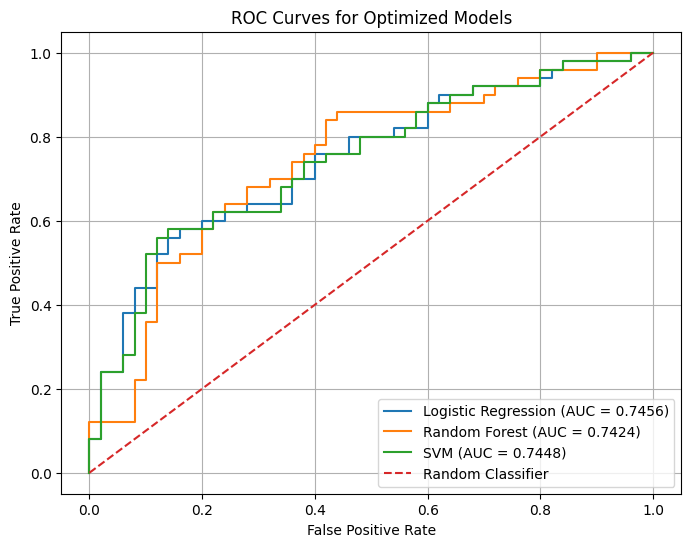

ROC-AUC Values
----------------
Logistic Regression: 0.7456
Random Forest      : 0.7424
SVM                : 0.7448


In [ ]:
# ============================================================
# 15. ROC-AUC ANALYSIS
# ============================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

# Calculate AUC values
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {auc_svm:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Optimized Models")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC Values")
print("----------------")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Random Forest      : {auc_rf:.4f}")
print(f"SVM                : {auc_svm:.4f}")

## 16. Best-Performing Model Selection

The optimized model with the highest test-set F1-score is selected as the best-performing model.

F1-score is used as the primary selection criterion because it provides a balance between precision and recall for the bioactivity classification task.

In [ ]:
# ============================================================
# 16. BEST-PERFORMING MODEL SELECTION
# ============================================================

# Identify the model with the highest test-set F1-score
best_model_index = results_df["F1-Score"].idxmax()

best_model_name = results_df.loc[
    best_model_index,
    "Model"
]

best_model = optimized_models[best_model_name]

print("=" * 60)
print("BEST-PERFORMING MODEL")
print("=" * 60)

print("Model:", best_model_name)
print(
    "Test-Set F1-Score:",
    round(results_df.loc[best_model_index, "F1-Score"], 4)
)

print("\nBest model selected successfully.")

BEST-PERFORMING MODEL
Model: Random Forest
Test-Set F1-Score: 0.6863

Best model selected successfully.


## 17. Interpretation of Model Performance

The three optimized machine-learning models were evaluated on the independent test dataset.

Random Forest achieved the highest test-set accuracy (0.680), precision (0.6731), recall (0.700), and F1-score (0.6863). Therefore, based on the F1-score used for model selection, Random Forest was identified as the best-performing model.

Logistic Regression achieved the highest ROC-AUC (0.7456), followed closely by SVM (0.7448) and Random Forest (0.7424). The small differences between the ROC-AUC values indicate that the three models have relatively similar discriminatory capabilities.

Since the dataset is synthetic, these results should be interpreted as a computational learning exercise rather than as experimentally validated bioactivity predictions.

In [ ]:
# ============================================================
# 17. INTERPRETATION OF MODEL PERFORMANCE
# ============================================================

# Identify the best model based on test-set F1-score
best_f1 = results_df["F1-Score"].max()

best_model_row = results_df.loc[
    results_df["F1-Score"].idxmax()
]

# Identify the model with the highest ROC-AUC
best_auc_row = results_df.loc[
    results_df["ROC-AUC"].idxmax()
]

print("=" * 65)
print("MODEL PERFORMANCE INTERPRETATION")
print("=" * 65)

print(
    f"\nBest model based on F1-score: "
    f"{best_model_row['Model']}"
)

print(
    f"F1-score: {best_model_row['F1-Score']:.4f}"
)

print(
    f"\nHighest ROC-AUC: "
    f"{best_auc_row['Model']}"
)

print(
    f"ROC-AUC: {best_auc_row['ROC-AUC']:.4f}"
)

print("\nTest-set performance summary:")
display(
    results_df[
        ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    ].round(4)
)

MODEL PERFORMANCE INTERPRETATION

Best model based on F1-score: Random Forest
F1-score: 0.6863

Highest ROC-AUC: Logistic Regression
ROC-AUC: 0.7456

Test-set performance summary:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.64,0.6400,0.64,0.6400,0.7456
1,Random Forest,0.68,0.6731,0.70,0.6863,0.7424
2,SVM,0.65,0.6596,0.62,0.6392,0.7448


## 18. Summary of Week 3 Findings

The predictive modeling workflow was completed using three machine-learning algorithms: Logistic Regression, Random Forest, and Support Vector Machine (SVM).

Random Forest produced the highest test-set F1-score of **0.6863** and was therefore selected as the best-performing model based on the primary model-selection criterion.

Although Logistic Regression achieved the highest ROC-AUC of **0.7456**, the ROC-AUC values of all three models were relatively close:

- Logistic Regression: **0.7456**
- SVM: **0.7448**
- Random Forest: **0.7424**

Overall, the results demonstrate the application of data preprocessing, hyperparameter tuning, model evaluation, and comparative analysis to a synthetic chemical-compound bioactivity classification dataset.

Because the dataset is synthetic, the findings are intended for educational and methodological purposes and should not be interpreted as experimentally validated predictions.

In [ ]:
# ============================================================
# 18. FINAL WEEK 3 RESULTS SUMMARY
# ============================================================

print("=" * 65)
print("FINAL WEEK 3 RESULTS SUMMARY")
print("=" * 65)

print("\nTest-set performance:")
display(results_df.round(4))

print("\nBest-performing model based on F1-score:")
print(best_model_name)

print(
    f"F1-Score: "
    f"{results_df.loc[best_model_index, 'F1-Score']:.4f}"
)

print("\nHighest ROC-AUC model:")
print(best_auc_row["Model"])

print(
    f"ROC-AUC: "
    f"{best_auc_row['ROC-AUC']:.4f}"
)

FINAL WEEK 3 RESULTS SUMMARY

Test-set performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.64,0.6400,0.64,0.6400,0.7456
1,Random Forest,0.68,0.6731,0.70,0.6863,0.7424
2,SVM,0.65,0.6596,0.62,0.6392,0.7448



Best-performing model based on F1-score:
Random Forest
F1-Score: 0.6863

Highest ROC-AUC model:
Logistic Regression
ROC-AUC: 0.7456


## 19. Model Performance Comparison Visualization

The performance of the three optimized machine-learning models is visualized using their test-set accuracy, precision, recall, and F1-score.

This visualization provides a direct comparison of the classification performance of Logistic Regression, Random Forest, and SVM.

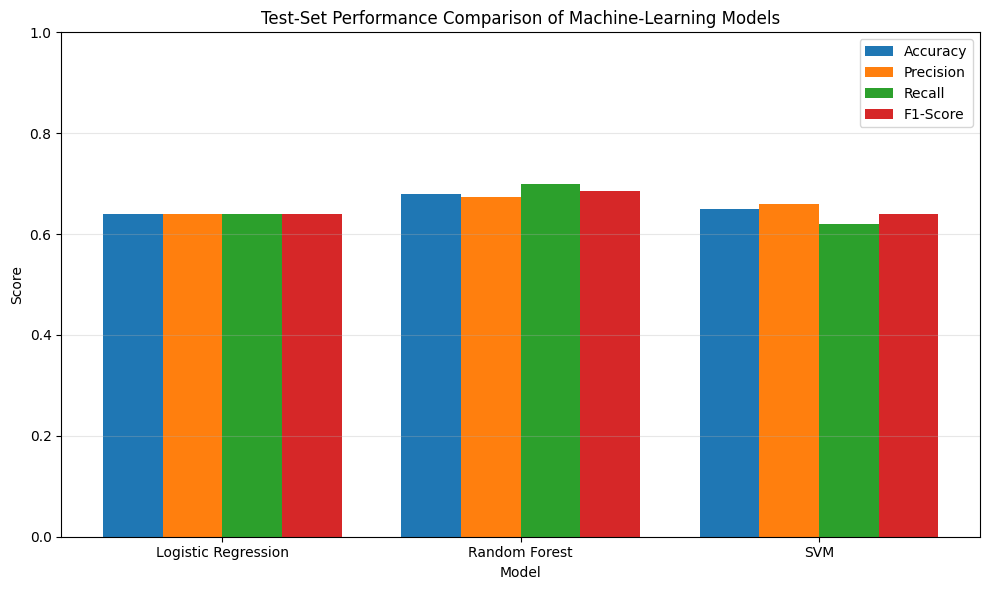

In [35]:
# ============================================================
# 19. MODEL PERFORMANCE COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

# Create Figures directory if it does not already exist
os.makedirs("../Figures", exist_ok=True)

# Metrics to visualize
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(results_df["Model"]))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        results_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    results_df["Model"]
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Test-Set Performance Comparison of Machine-Learning Models")

plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(
    "../Figures/week3_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Confusion Matrix Visualization

Confusion matrices are visualized for the three optimized models to illustrate correct and incorrect classifications of Active and Inactive compounds.

The matrices are based on predictions from the independent test dataset.

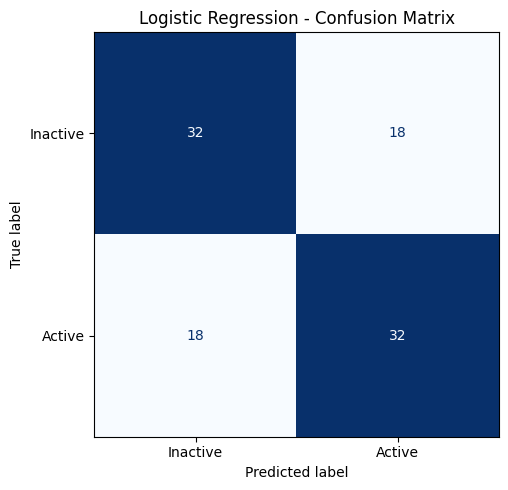

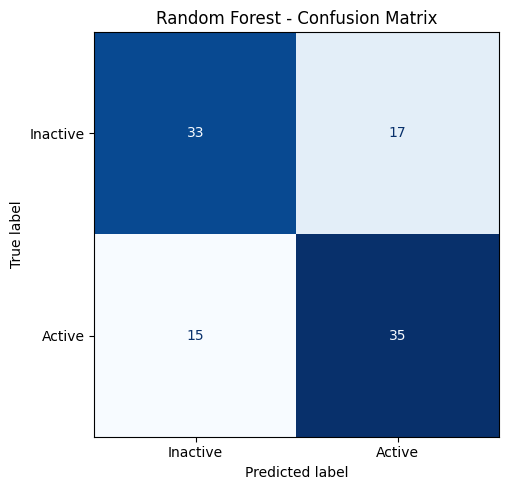

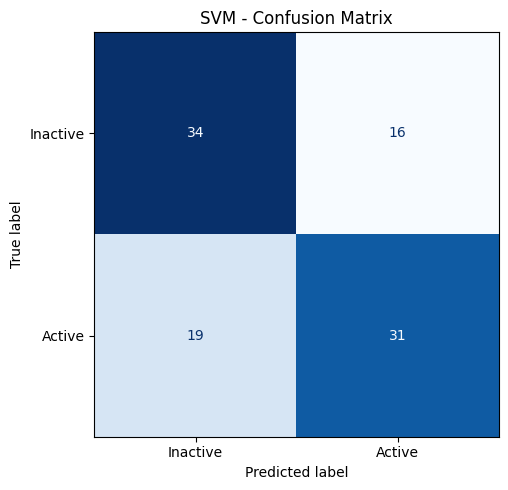

In [36]:
# ============================================================
# 20. CONFUSION MATRIX VISUALIZATION
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

figures = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for name, y_pred in figures.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Inactive", "Active"]
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(f"{name} - Confusion Matrix")

    plt.tight_layout()

    # Create a safe filename
    filename = name.lower().replace(" ", "_")

    plt.savefig(
        f"../Figures/week3_{filename}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 21. Conclusion

The Week 3 predictive modeling workflow successfully implemented Logistic Regression, Random Forest, and Support Vector Machine (SVM) for bioactivity classification using the synthetic chemical-compound dataset.

Among the three models, Random Forest achieved the highest test-set F1-score (0.6863) and was therefore selected as the best-performing model based on the primary model-selection criterion.

Logistic Regression achieved the highest ROC-AUC (0.7456), followed by SVM (0.7448) and Random Forest (0.7424). The relatively small differences in ROC-AUC indicate that the three models demonstrated similar overall discriminatory capabilities.

The results demonstrate the application of feature preprocessing, hyperparameter tuning, cross-validation, predictive modeling, and model evaluation in a healthcare-related computational data science workflow.

Because the dataset is synthetic, these findings are intended for educational and methodological purposes and should not be interpreted as experimentally validated bioactivity predictions.